# Aggregated Scalar Conclusions

- experiment generation under `agentic/scalar_experiments/outputs/`
- aggregation via `agentic/scalar_experiments/scripts/aggregate_conclusions.py`

Assumes `agentic/scalar_experiments/aggregated_results.csv` exists.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

BASE_DIR = Path("..").resolve()
CSV_PATH = BASE_DIR / "aggregated_results.csv"

CSV_PATH

PosixPath('/accounts/grad/zachrewolinski/research/stat-genie/agentic/scalar_experiments/aggregated_results.csv')

In [2]:
if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Expected aggregated results at {CSV_PATH}. "
        "Run scripts/aggregate_conclusions.py first."
    )

# keep_default_na=False so the literal "null" in distribution is not read as NaN
df = pd.read_csv(CSV_PATH, keep_default_na=False)
datasets = sorted(df["dataset"].unique())
print(f"Found {len(datasets)} datasets: {datasets}")
df

Found 5 datasets: ['affairs', 'amtl', 'boxes', 'caschools', 'crofoot']


,dataset,distribution,perturbation,run_id,response,explanation
0,affairs,alt,add_features,1,10,The research question asks whether having chil...
1,affairs,alt,add_features,2,40,Among the 601 married individuals in this data...
2,affairs,alt,add_features,3,10,Using 601 married individuals from the affairs...
3,affairs,alt,add_features,4,40,Research question: Does having children decrea...
4,affairs,alt,add_features,5,5,Using the 1969 Psychology Today extramarital a...
...,...,...,...,...,...,...
914,crofoot,null,shuffle_names,16,15,Our analysis modeled the probability that the ...
915,crofoot,null,shuffle_names,17,20,Research question: Do relative group size and ...
916,crofoot,null,shuffle_names,18,20,"Using 58 intergroup contests, I modeled a bina..."
917,crofoot,null,shuffle_names,19,20,Using logistic regression models on 58 intergr...


In [3]:
null_scores = df.loc[df["distribution"] == "null", "response"].reset_index(drop=True)
alt_scores  = df.loc[df["distribution"] == "alt",  "response"].reset_index(drop=True)

print(f"null  n={len(null_scores):,}  mean={null_scores.mean():.2f}  median={null_scores.median():.2f}  std={null_scores.std():.2f}")
print(f"alt   n={len(alt_scores):,}  mean={alt_scores.mean():.2f}  median={alt_scores.median():.2f}  std={alt_scores.std():.2f}")

null  n=498  mean=25.78  median=20.00  std=16.33
alt   n=421  mean=50.20  median=40.00  std=31.07


In [4]:
# Cell 4 — helper functions (replace existing)
rng = np.random.default_rng(42)
X_GRID = np.linspace(0, 100, 1000)


def tail_mass_pvalue(null: pd.Series, threshold: float) -> float:
    return (null >= threshold).sum() / len(null)


def overlap_coefficient(a: np.ndarray, b: np.ndarray, x_grid: np.ndarray = X_GRID) -> float:
    kde_a = stats.gaussian_kde(a)
    kde_b = stats.gaussian_kde(b)
    return float(np.trapz(np.minimum(kde_a(x_grid), kde_b(x_grid)), x_grid))


DATASET: affairs
  null  n=100  mean=30.45  median=25.00  std=19.12
  alt   n=98  mean=20.80  median=15.00  std=14.82


/tmp/ipykernel_1305333/85364497.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="distribution", y="response",
/tmp/ipykernel_1305333/85364497.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="distribution", y="response",


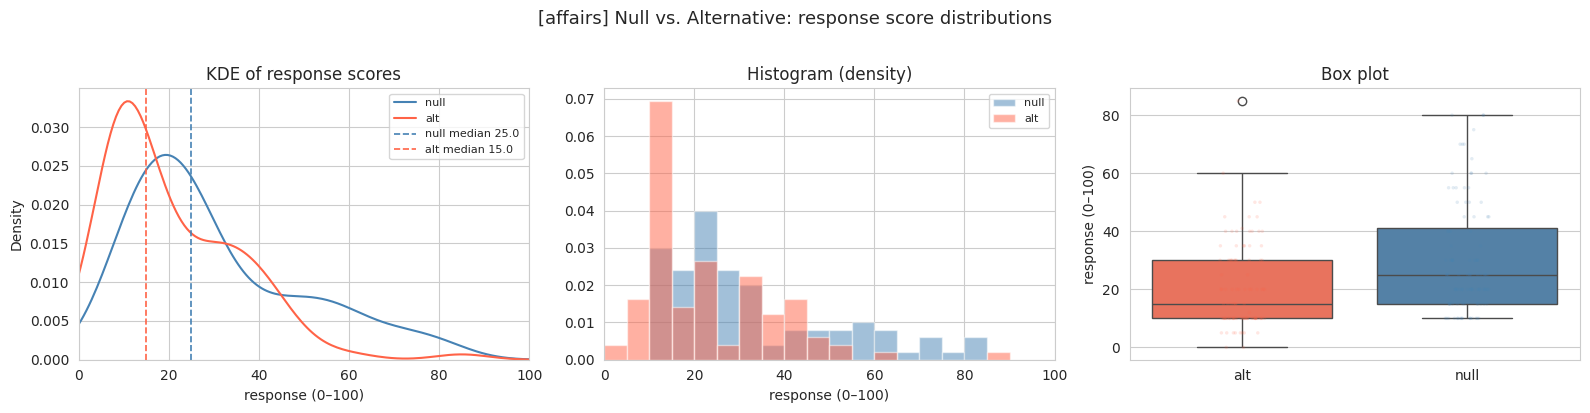

  Alt median : 15.00  →  p = 0.8500
  Alt mean   : 20.80  →  p = 0.5300


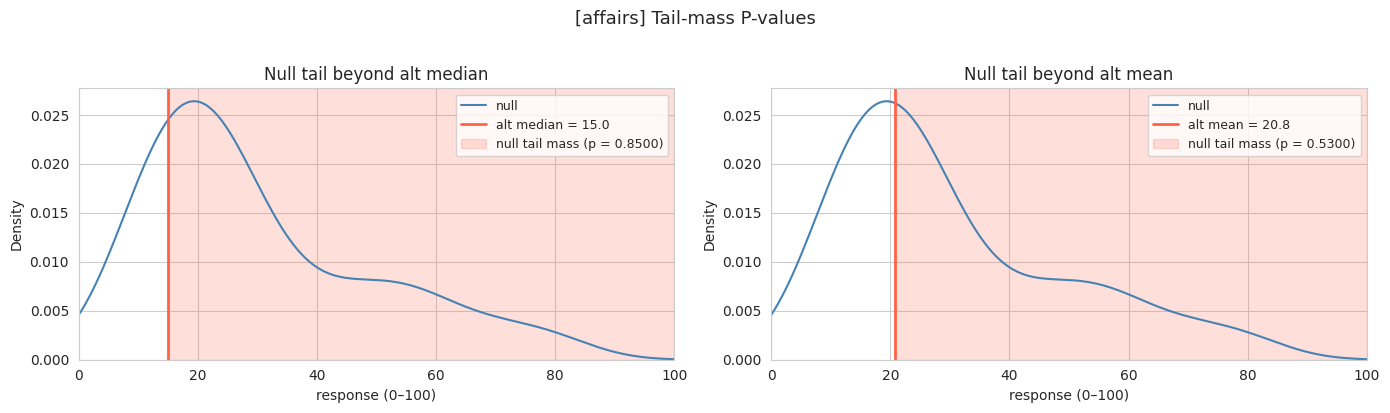

  OVL        : 0.7521  →  p = 0.0005  (2000 permutations)


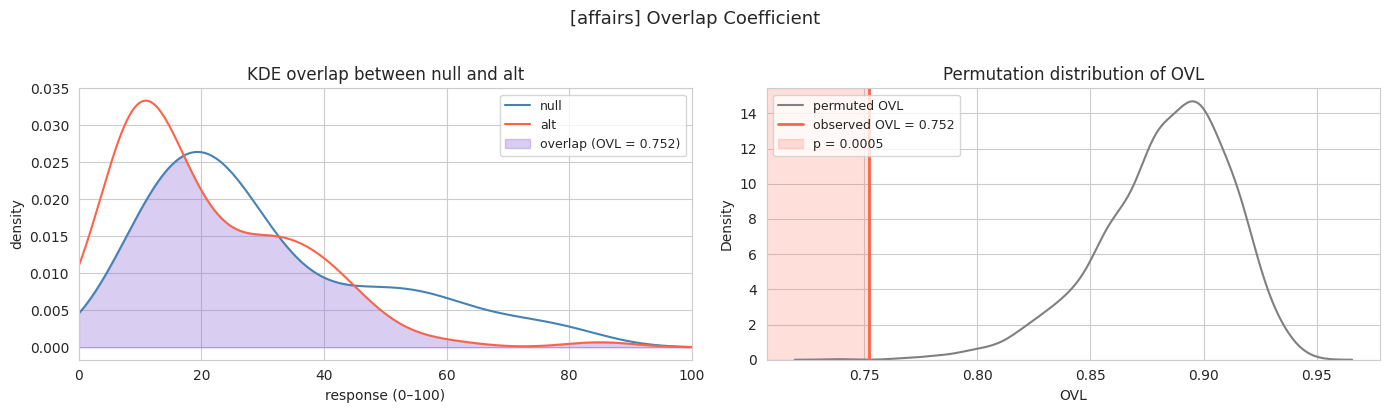


DATASET: amtl
  null  n=99  mean=26.57  median=20.00  std=16.58
  alt   n=100  mean=93.85  median=95.00  std=6.56


/tmp/ipykernel_1305333/85364497.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="distribution", y="response",
/tmp/ipykernel_1305333/85364497.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="distribution", y="response",


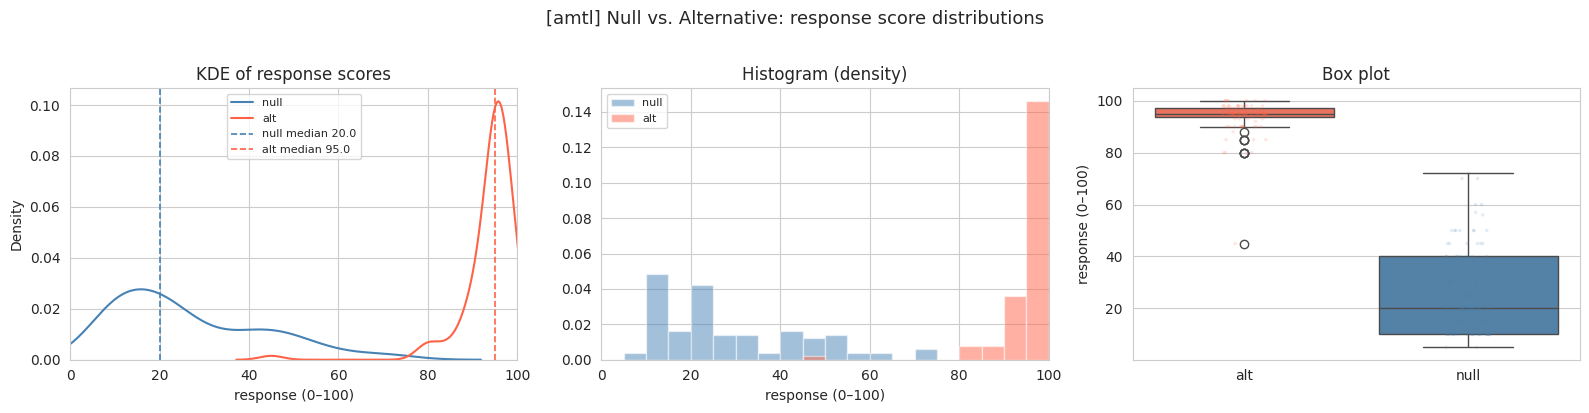

  Alt median : 95.00  →  p = 0.0000
  Alt mean   : 93.85  →  p = 0.0000


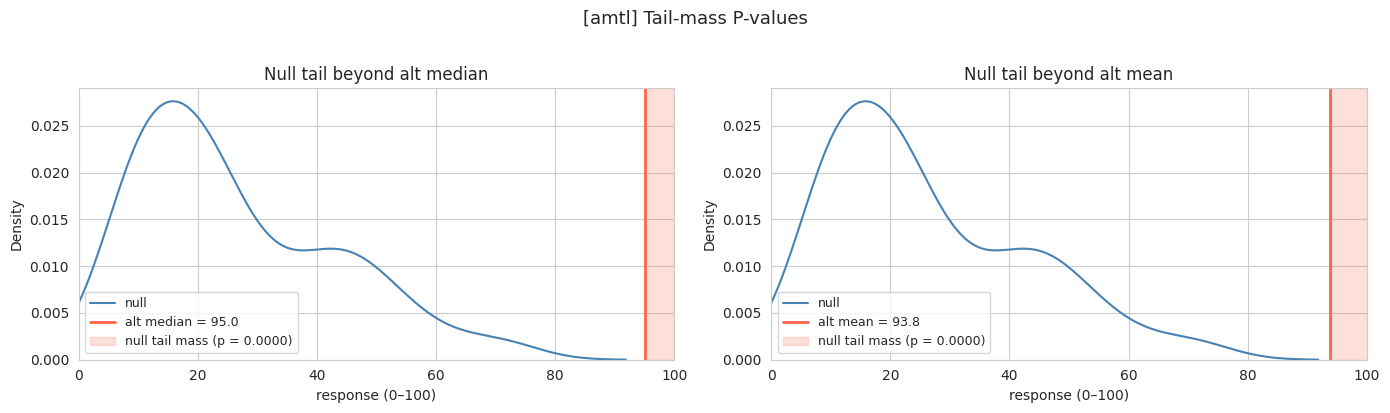

  OVL        : 0.0190  →  p = 0.0000  (2000 permutations)


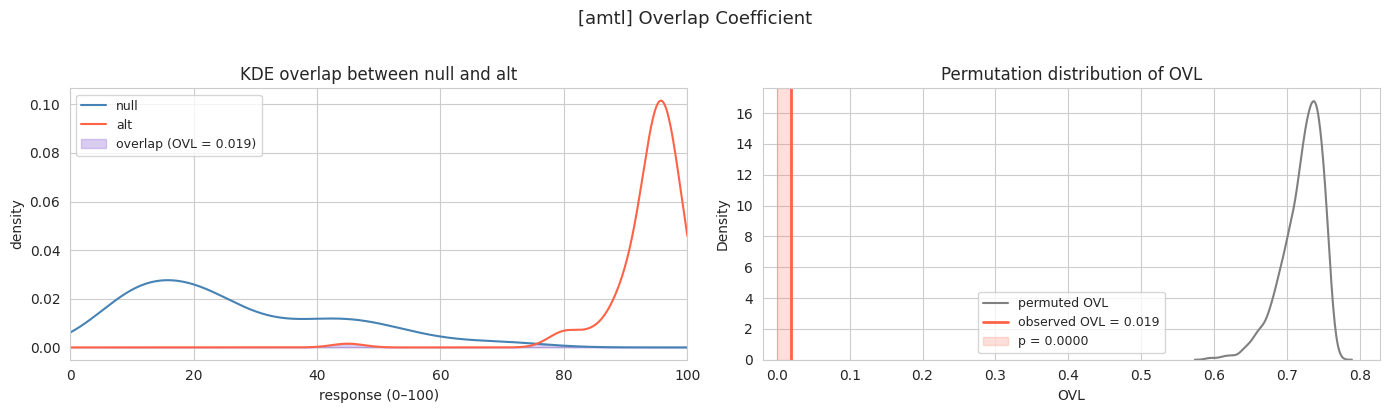


DATASET: boxes
  null  n=100  mean=31.93  median=25.00  std=19.67
  alt   n=99  mean=34.61  median=30.00  std=16.64


/tmp/ipykernel_1305333/85364497.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="distribution", y="response",
/tmp/ipykernel_1305333/85364497.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="distribution", y="response",


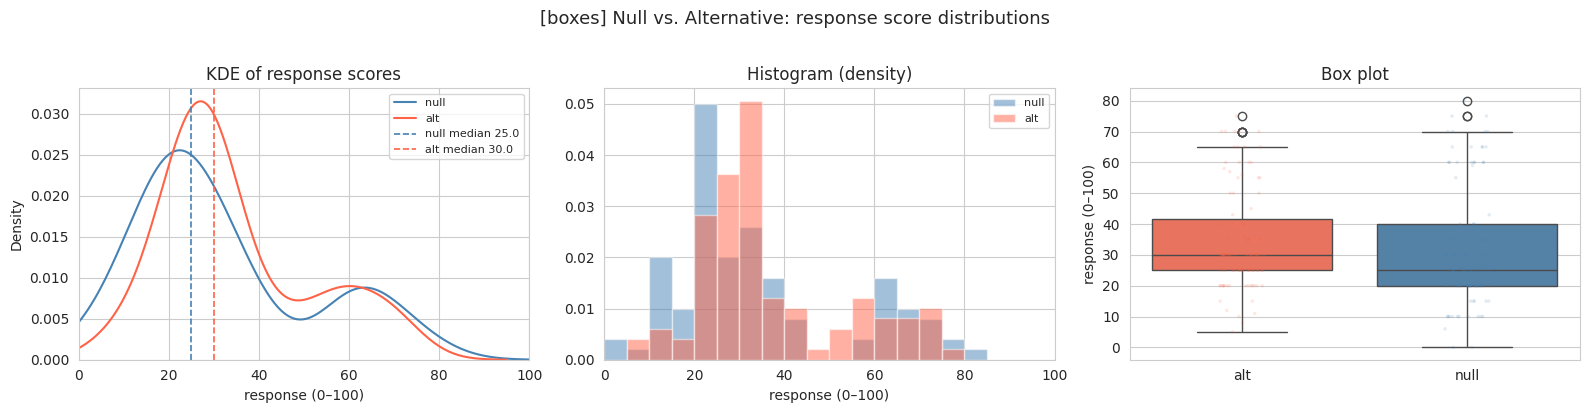

  Alt median : 30.00  →  p = 0.4700
  Alt mean   : 34.61  →  p = 0.3400


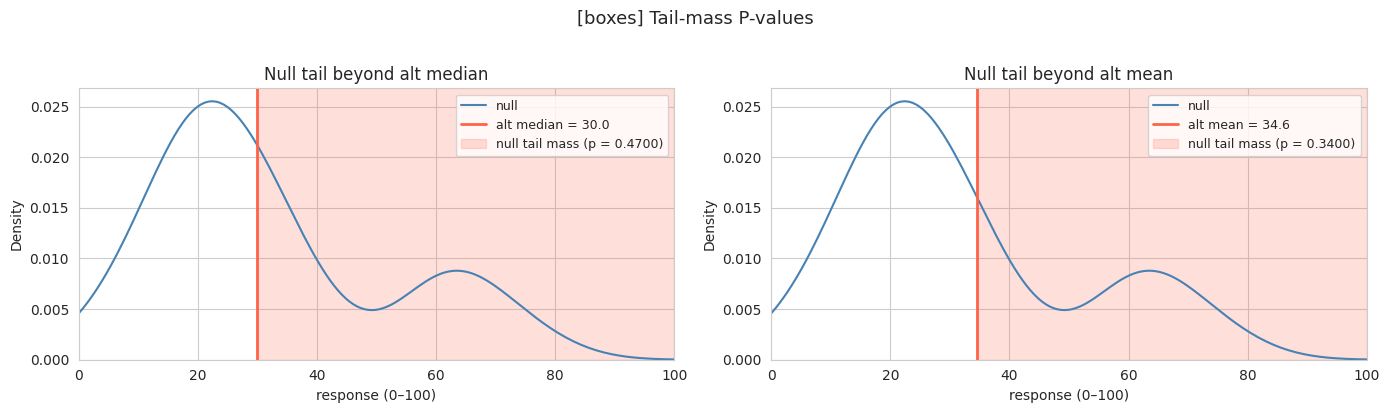

  OVL        : 0.8400  →  p = 0.0370  (2000 permutations)


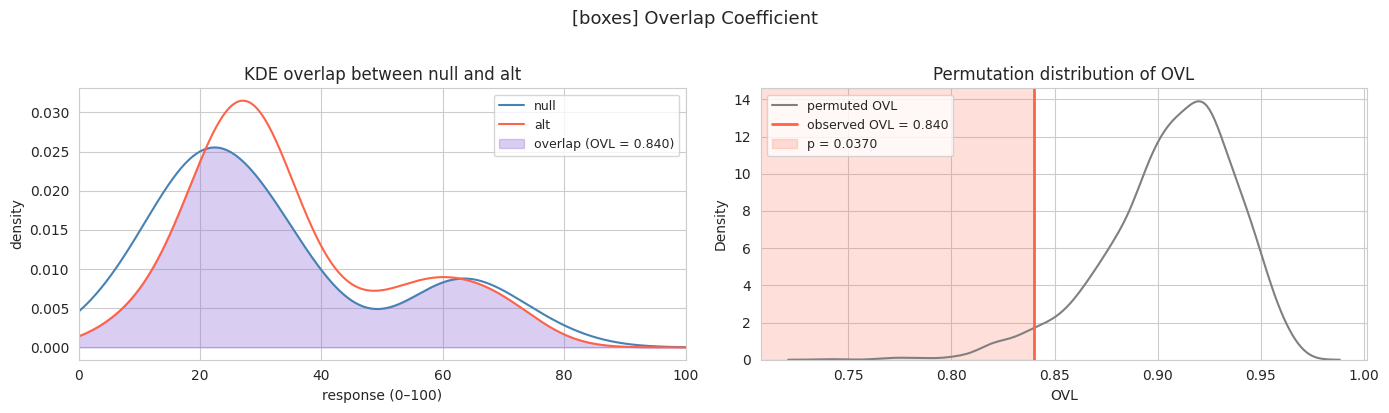


DATASET: caschools
  null  n=100  mean=17.26  median=10.00  std=11.14
  alt   n=99  mean=55.97  median=60.00  std=19.93


/tmp/ipykernel_1305333/85364497.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="distribution", y="response",
/tmp/ipykernel_1305333/85364497.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="distribution", y="response",


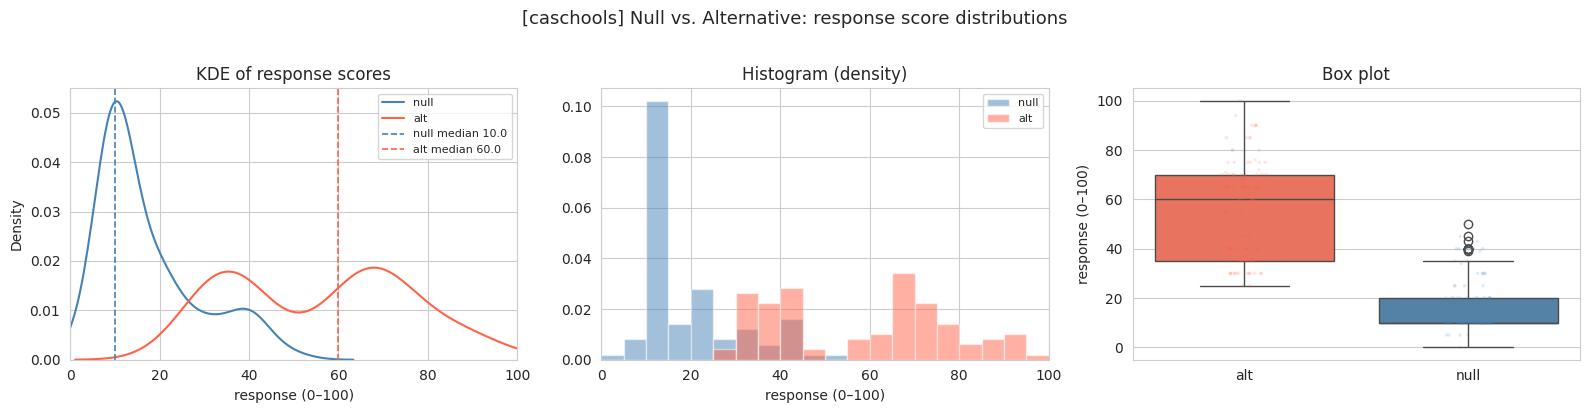

  Alt median : 60.00  →  p = 0.0000
  Alt mean   : 55.97  →  p = 0.0000


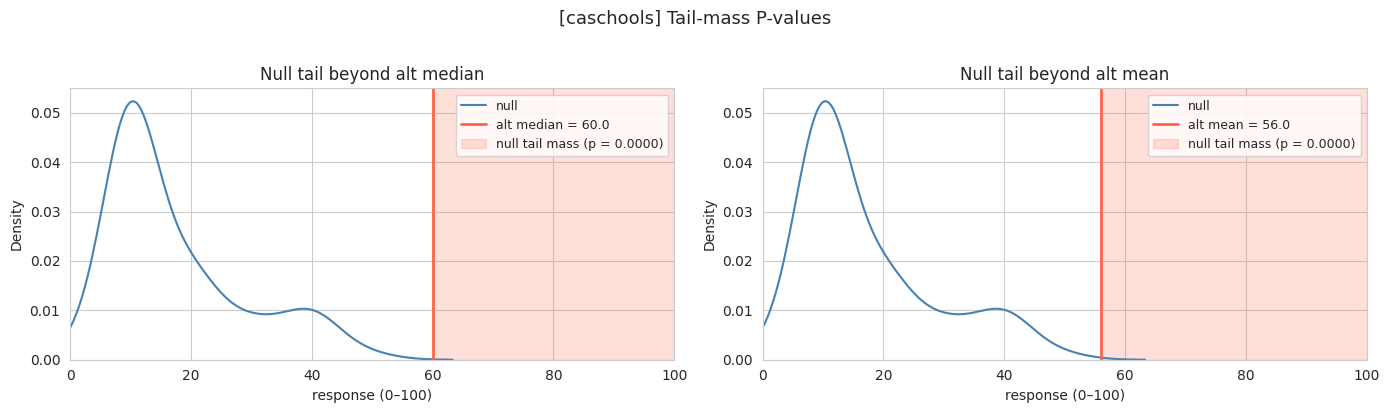

  OVL        : 0.2805  →  p = 0.0000  (2000 permutations)


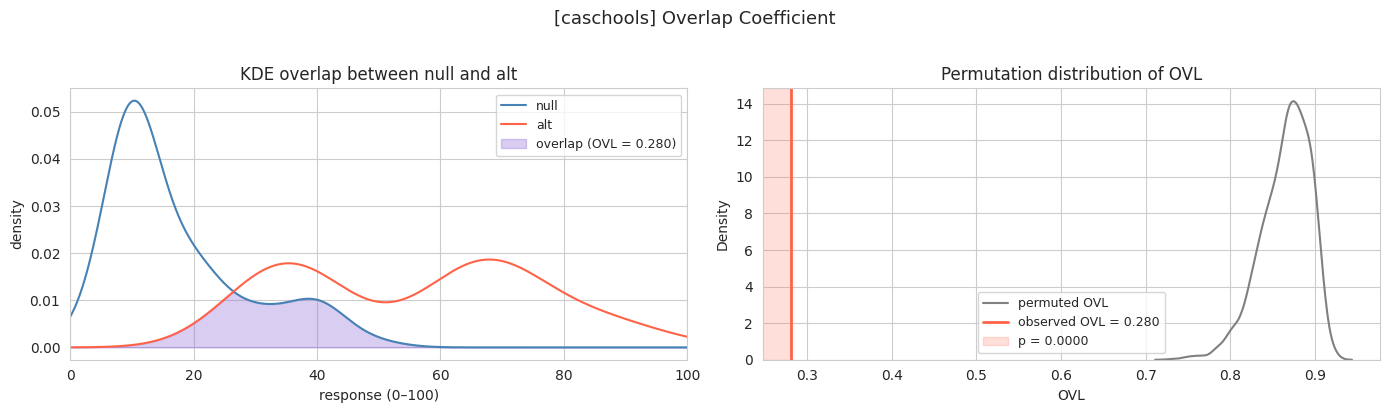


DATASET: crofoot
  null  n=99  mean=22.66  median=20.00  std=6.78
  alt   n=25  mean=29.80  median=30.00  std=5.49


/tmp/ipykernel_1305333/85364497.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="distribution", y="response",
/tmp/ipykernel_1305333/85364497.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="distribution", y="response",


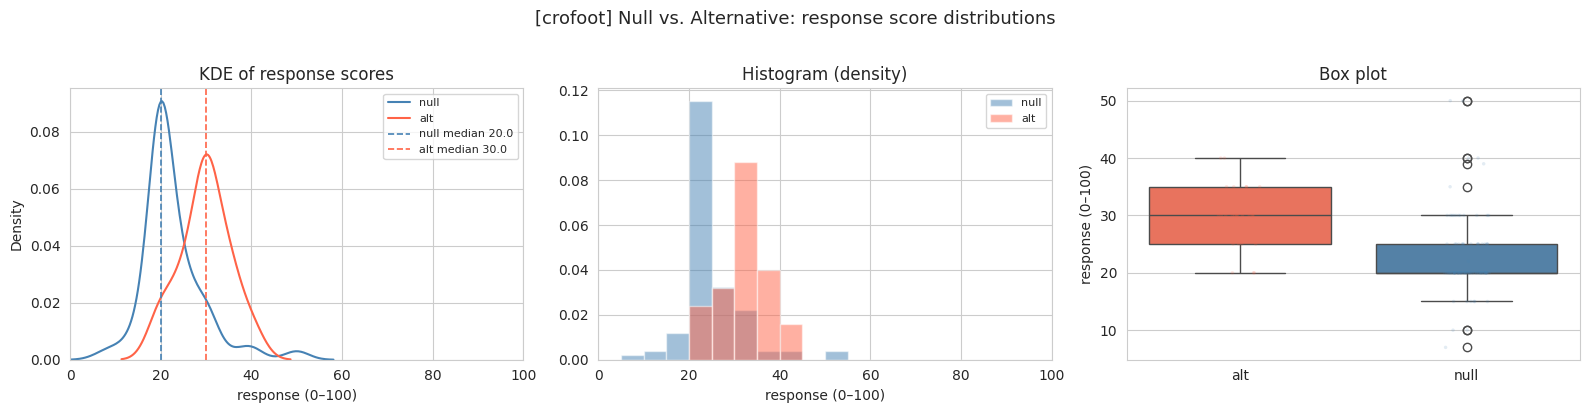

  Alt median : 30.00  →  p = 0.1717
  Alt mean   : 29.80  →  p = 0.1717


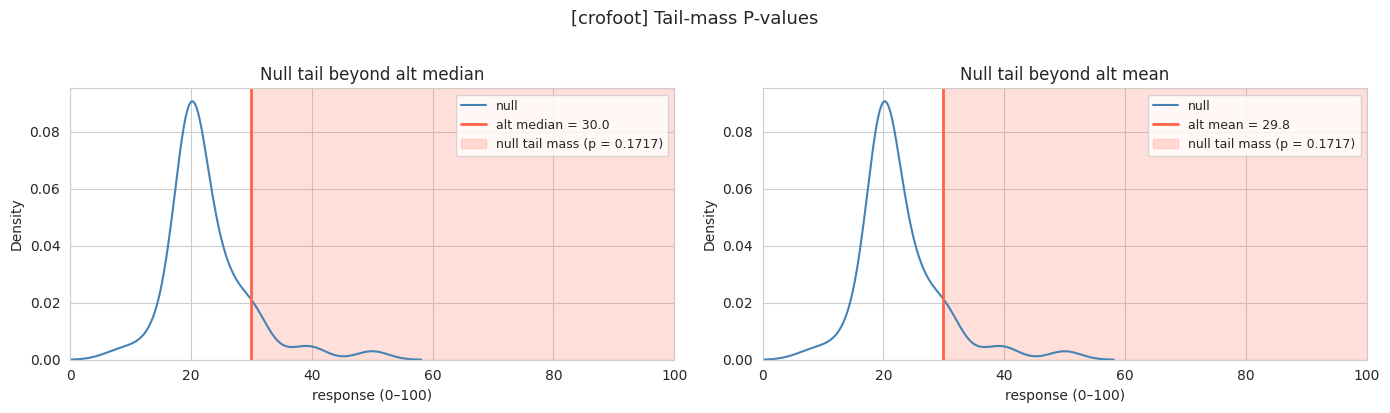

  OVL        : 0.4640  →  p = 0.0000  (2000 permutations)


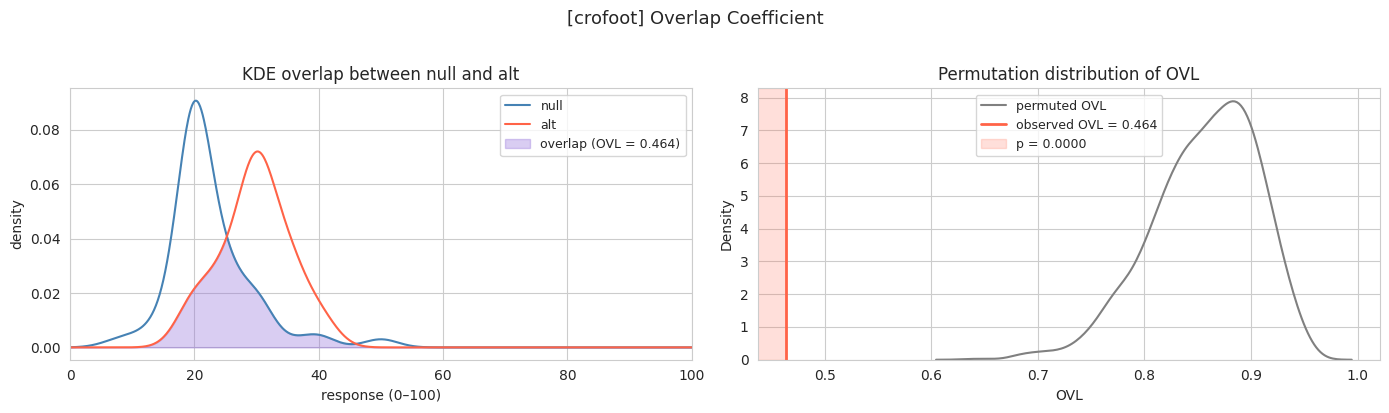

In [5]:
# Cell 5 — per-dataset loop (replace all remaining cells)
N_PERM = 2000
all_summaries = []

for dataset_name in datasets:
    sub = df[df["dataset"] == dataset_name]
    null_scores = sub.loc[sub["distribution"] == "null", "response"].reset_index(drop=True)
    alt_scores  = sub.loc[sub["distribution"] == "alt",  "response"].reset_index(drop=True)

    if len(null_scores) < 2 or len(alt_scores) < 2:
        print(f"\n{'='*80}")
        print(f"DATASET: {dataset_name}  — skipping (null n={len(null_scores)}, alt n={len(alt_scores)})")
        continue

    # ── summary stats ──
    print(f"\n{'='*80}")
    print(f"DATASET: {dataset_name}")
    print(f"  null  n={len(null_scores):,}  mean={null_scores.mean():.2f}  median={null_scores.median():.2f}  std={null_scores.std():.2f}")
    print(f"  alt   n={len(alt_scores):,}  mean={alt_scores.mean():.2f}  median={alt_scores.median():.2f}  std={alt_scores.std():.2f}")

    # ── distribution plots ──
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    ax = axes[0]
    sns.kdeplot(null_scores, ax=ax, label="null", color="steelblue", common_norm=False)
    sns.kdeplot(alt_scores,  ax=ax, label="alt",  color="tomato",    common_norm=False)
    ax.axvline(null_scores.median(), color="steelblue", linestyle="--", linewidth=1.2,
               label=f"null median {null_scores.median():.1f}")
    ax.axvline(alt_scores.median(),  color="tomato",    linestyle="--", linewidth=1.2,
               label=f"alt median {alt_scores.median():.1f}")
    ax.set_title("KDE of response scores")
    ax.set_xlabel("response (0–100)")
    ax.set_xlim(0, 100)
    ax.legend(fontsize=8)

    ax = axes[1]
    bins = range(0, 102, 5)
    ax.hist(null_scores, bins=bins, alpha=0.5, color="steelblue", label="null", density=True)
    ax.hist(alt_scores,  bins=bins, alpha=0.5, color="tomato",    label="alt",  density=True)
    ax.set_title("Histogram (density)")
    ax.set_xlabel("response (0–100)")
    ax.set_xlim(0, 100)
    ax.legend(fontsize=8)

    ax = axes[2]
    plot_df = sub[sub["distribution"].isin(["null", "alt"])][["distribution", "response"]]
    sns.boxplot(data=plot_df, x="distribution", y="response",
                palette={"null": "steelblue", "alt": "tomato"}, ax=ax)
    sns.stripplot(data=plot_df, x="distribution", y="response",
                  palette={"null": "steelblue", "alt": "tomato"},
                  alpha=0.15, size=2.5, jitter=True, ax=ax)
    ax.set_title("Box plot")
    ax.set_xlabel("")
    ax.set_ylabel("response (0–100)")

    plt.suptitle(f"[{dataset_name}] Null vs. Alternative: response score distributions",
                 y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── tail-mass p-values ──
    alt_median = alt_scores.median()
    alt_mean   = alt_scores.mean()
    p_median = tail_mass_pvalue(null_scores, alt_median)
    p_mean   = tail_mass_pvalue(null_scores, alt_mean)

    print(f"  Alt median : {alt_median:.2f}  →  p = {p_median:.4f}")
    print(f"  Alt mean   : {alt_mean:.2f}  →  p = {p_mean:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for i, (threshold, p_val, lbl) in enumerate([
        (alt_median, p_median, "median"),
        (alt_mean,   p_mean,   "mean"),
    ]):
        ax = axes[i]
        sns.kdeplot(null_scores, ax=ax, color="steelblue", label="null", common_norm=False)
        ax.axvline(threshold, color="tomato", linewidth=2, linestyle="-",
                   label=f"alt {lbl} = {threshold:.1f}")
        ax.fill_betweenx(
            [0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1],
            threshold, 100,
            alpha=0.2, color="tomato",
            label=f"null tail mass (p = {p_val:.4f})",
        )
        ax.relim(); ax.autoscale_view()
        ax.set_title(f"Null tail beyond alt {lbl}")
        ax.set_xlabel("response (0–100)")
        ax.set_xlim(0, 100)
        ax.legend(fontsize=9)

    plt.suptitle(f"[{dataset_name}] Tail-mass P-values", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── overlap coefficient + permutation test ──
    null_arr = null_scores.to_numpy().astype(float)
    alt_arr  = alt_scores.to_numpy().astype(float)
    observed_ovl = overlap_coefficient(null_arr, alt_arr)

    n_null   = len(null_arr)
    combined = np.concatenate([null_arr, alt_arr])

    perm_ovls = np.empty(N_PERM)
    for j in range(N_PERM):
        shuffled = rng.permutation(combined)
        perm_ovls[j] = overlap_coefficient(shuffled[:n_null], shuffled[n_null:])

    p_ovl = float((perm_ovls <= observed_ovl).mean())
    print(f"  OVL        : {observed_ovl:.4f}  →  p = {p_ovl:.4f}  ({N_PERM} permutations)")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    kde_null = stats.gaussian_kde(null_arr)
    kde_alt  = stats.gaussian_kde(alt_arr)
    y_null = kde_null(X_GRID)
    y_alt  = kde_alt(X_GRID)
    ax.plot(X_GRID, y_null, color="steelblue", label="null")
    ax.plot(X_GRID, y_alt,  color="tomato",    label="alt")
    ax.fill_between(X_GRID, np.minimum(y_null, y_alt), alpha=0.35, color="mediumpurple",
                    label=f"overlap (OVL = {observed_ovl:.3f})")
    ax.set_title("KDE overlap between null and alt")
    ax.set_xlabel("response (0–100)")
    ax.set_ylabel("density")
    ax.set_xlim(0, 100)
    ax.legend(fontsize=9)

    ax = axes[1]
    sns.kdeplot(perm_ovls, ax=ax, color="gray", common_norm=False, label="permuted OVL")
    ax.axvline(observed_ovl, color="tomato", linewidth=2, linestyle="-",
               label=f"observed OVL = {observed_ovl:.3f}")
    ax.fill_betweenx(
        [0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1],
        0, observed_ovl,
        alpha=0.2, color="tomato",
        label=f"p = {p_ovl:.4f}",
    )
    ax.relim(); ax.autoscale_view()
    ax.set_title("Permutation distribution of OVL")
    ax.set_xlabel("OVL")
    ax.legend(fontsize=9)

    plt.suptitle(f"[{dataset_name}] Overlap Coefficient", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── collect summary row ──
    all_summaries.append({
        "dataset": dataset_name,
        "null_n": len(null_scores),
        "alt_n": len(alt_scores),
        "null_mean": null_scores.mean(),
        "alt_mean": alt_scores.mean(),
        "null_median": null_scores.median(),
        "alt_median": alt_scores.median(),
        "p_tail_median": p_median,
        "p_tail_mean": p_mean,
        "ovl": observed_ovl,
        "p_ovl": p_ovl,
    })

In [6]:
# Cell 6 — aggregate summary table
summary_df = pd.DataFrame(all_summaries)
summary_df

,dataset,null_n,alt_n,null_mean,alt_mean,null_median,alt_median,p_tail_median,p_tail_mean,ovl,p_ovl
0,affairs,100,98,30.450000,20.795918,25.0,15.0,0.850000,0.530000,0.752080,0.0005
1,amtl,99,100,26.565657,93.850000,20.0,95.0,0.000000,0.000000,0.019042,0.0000
2,boxes,100,99,31.930000,34.606061,25.0,30.0,0.470000,0.340000,0.840043,0.0370
3,caschools,100,99,17.260000,55.969697,10.0,60.0,0.000000,0.000000,0.280486,0.0000
4,crofoot,99,25,22.656566,29.800000,20.0,30.0,0.171717,0.171717,0.463966,0.0000


## Distributions

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
sns.kdeplot(null_scores, ax=ax, label="null", color="steelblue", common_norm=False)
sns.kdeplot(alt_scores,  ax=ax, label="alt",  color="tomato",    common_norm=False)
ax.axvline(null_scores.median(), color="steelblue", linestyle="--", linewidth=1.2, label=f"null median {null_scores.median():.1f}")
ax.axvline(alt_scores.median(),  color="tomato",    linestyle="--", linewidth=1.2, label=f"alt median {alt_scores.median():.1f}")
ax.set_title("KDE of response scores")
ax.set_xlabel("response (0–100)")
ax.set_xlim(0, 100)
ax.legend(fontsize=8)

ax = axes[1]
bins = range(0, 102, 5)
ax.hist(null_scores, bins=bins, alpha=0.5, color="steelblue", label="null", density=True)
ax.hist(alt_scores,  bins=bins, alpha=0.5, color="tomato",    label="alt",  density=True)
ax.set_title("Histogram (density)")
ax.set_xlabel("response (0–100)")
ax.set_xlim(0, 100)
ax.legend(fontsize=8)

ax = axes[2]
plot_df = df[df["distribution"].isin(["null", "alt"])][["distribution", "response"]]
sns.boxplot(data=plot_df, x="distribution", y="response", palette={"null": "steelblue", "alt": "tomato"}, ax=ax)
sns.stripplot(data=plot_df, x="distribution", y="response", palette={"null": "steelblue", "alt": "tomato"},
              alpha=0.15, size=2.5, jitter=True, ax=ax)
ax.set_title("Box plot")
ax.set_xlabel("")
ax.set_ylabel("response (0–100)")

plt.suptitle("Null vs. Alternative: response score distributions", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## Tail-mass P-values

What fraction of null scores are >= the alt median (or mean)? Simple empirical one-sided p-value.

In [ ]:
def tail_mass_pvalue(null: pd.Series, threshold: float) -> float:
    return (null >= threshold).sum() / len(null)


alt_median = alt_scores.median()
p_median = tail_mass_pvalue(null_scores, alt_median)

print(f"Alt median : {alt_median:.2f}")
print(f"P-value    : {p_median:.4f}  ({p_median*100:.2f}% of null scores >= alt median)")

fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(null_scores, ax=ax, color="steelblue", label="null", common_norm=False)
ax.axvline(alt_median, color="tomato", linewidth=2, linestyle="-", label=f"alt median = {alt_median:.1f}")
ax.fill_betweenx(
    [0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1],
    alt_median, 100,
    alpha=0.2, color="tomato",
    label=f"null tail mass (p = {p_median:.4f})",
)
ax.relim(); ax.autoscale_view()
ax.set_title("Null distribution — tail beyond alt median")
ax.set_xlabel("response (0–100)")
ax.set_xlim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
alt_mean = alt_scores.mean()
p_mean = tail_mass_pvalue(null_scores, alt_mean)

print(f"Alt mean   : {alt_mean:.2f}")
print(f"P-value    : {p_mean:.4f}  ({p_mean*100:.2f}% of null scores >= alt mean)")

fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(null_scores, ax=ax, color="steelblue", label="null", common_norm=False)
ax.axvline(alt_mean, color="tomato", linewidth=2, linestyle="-", label=f"alt mean = {alt_mean:.1f}")
ax.fill_betweenx(
    [0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1],
    alt_mean, 100,
    alpha=0.2, color="tomato",
    label=f"null tail mass (p = {p_mean:.4f})",
)
ax.relim(); ax.autoscale_view()
ax.set_title("Null distribution - tail beyond alt mean")
ax.set_xlabel("response (0–100)")
ax.set_xlim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
summary = pd.DataFrame({
    "threshold_name": ["alt median", "alt mean"],
    "threshold_value": [alt_median, alt_mean],
    "p_value": [p_median, p_mean],
    "null_n": [len(null_scores), len(null_scores)],
    "null_n_extreme": [(null_scores >= alt_median).sum(), (null_scores >= alt_mean).sum()],
})
summary

## Overlap Coefficient P-value

OVL = integral of min(f_null, f_alt). Rranges from 0 (no overlap) to 1 (identical). Permutation test to get a p-value: shuffle labels, recompute OVL, see how often we'd get separation this large by chance.

In [ ]:
import numpy as np
from scipy import stats

rng = np.random.default_rng(42)
X_GRID = np.linspace(0, 100, 1000)


def overlap_coefficient(a: np.ndarray, b: np.ndarray, x_grid: np.ndarray = X_GRID) -> float:
    kde_a = stats.gaussian_kde(a)
    kde_b = stats.gaussian_kde(b)
    return float(np.trapz(np.minimum(kde_a(x_grid), kde_b(x_grid)), x_grid))


null_arr = null_scores.to_numpy()
alt_arr  = alt_scores.to_numpy()
observed_ovl = overlap_coefficient(null_arr, alt_arr)

N_PERM = 2000
n_null = len(null_arr)
combined = np.concatenate([null_arr, alt_arr])

perm_ovls = np.empty(N_PERM)
for i in range(N_PERM):
    shuffled = rng.permutation(combined)
    perm_ovls[i] = overlap_coefficient(shuffled[:n_null], shuffled[n_null:])

p_ovl = float((perm_ovls <= observed_ovl).mean())

print(f"Observed OVL : {observed_ovl:.4f}")
print(f"P-value      : {p_ovl:.4f}  (fraction of {N_PERM} permutations with OVL <= observed)")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
kde_null = stats.gaussian_kde(null_arr)
kde_alt  = stats.gaussian_kde(alt_arr)
y_null = kde_null(X_GRID)
y_alt  = kde_alt(X_GRID)

ax.plot(X_GRID, y_null, color="steelblue", label="null")
ax.plot(X_GRID, y_alt,  color="tomato",    label="alt")
ax.fill_between(X_GRID, np.minimum(y_null, y_alt), alpha=0.35, color="mediumpurple",
                label=f"overlap (OVL = {observed_ovl:.3f})")
ax.set_title("KDE overlap between null and alt")
ax.set_xlabel("response (0–100)")
ax.set_ylabel("density")
ax.set_xlim(0, 100)
ax.legend(fontsize=9)

ax = axes[1]
sns.kdeplot(perm_ovls, ax=ax, color="gray", common_norm=False, label="permuted OVL")
ax.axvline(observed_ovl, color="tomato", linewidth=2, linestyle="-",
           label=f"observed OVL = {observed_ovl:.3f}")
ax.fill_betweenx(
    [0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1],
    0, observed_ovl,
    alpha=0.2, color="tomato",
    label=f"p = {p_ovl:.4f}",
)
ax.relim(); ax.autoscale_view()
ax.set_title("Permutation distribution of OVL")
ax.set_xlabel("OVL")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()